# Exploring Data from Temperatures, Pressures and Coolant Chambers on Vessels in a Fleet

In [ ]:
1.1 Missing and duplicate values in the data are identified or reported as non-existent.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
warnings.filterwarnings('ignore')

# Load the dataset
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'
df = pd.read_csv(url)

# Set a grid and colour scheme
sns.set_style('whitegrid')
palette = sns.color_palette("magma", as_cmap=False)

# Apply the colour scheme to global plots
sns.set_palette(palette)

# Rename columns for consistency
df.rename(columns={'lub oil temp': 'Lub oil temp'}, inplace=True)

# Convert types
df['Engine rpm'] = df['Engine rpm'].astype(float)

# Check for nulls and duplicates
print("Shape of dataset:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape of dataset: (19535, 6)
Missing values: 0
Duplicate rows: 0


# Initial Data Exploration

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# 1.2 The descriptive statistics of the data set are generated.

In [2]:
# Descriptive statistics
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,Lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


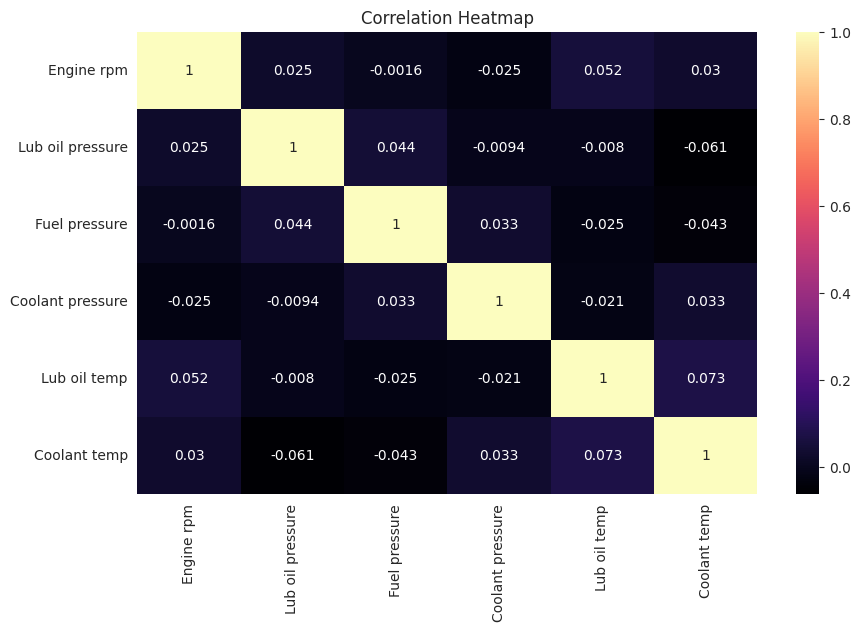

In [3]:
# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='magma') # cmap set in cell 1
plt.title('Correlation Heatmap')
plt.show()

# 1.3 The Mean and Median for each feature are documented

In [4]:
# Mean and median for each feature collated
for col in df.columns:
    print(f"{col} - Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}")

Engine rpm - Mean: 791.24, Median: 746.00
Lub oil pressure - Mean: 3.30, Median: 3.16
Fuel pressure - Mean: 6.66, Median: 6.20
Coolant pressure - Mean: 2.34, Median: 2.17
Lub oil temp - Mean: 77.64, Median: 76.82
Coolant temp - Mean: 78.43, Median: 78.35


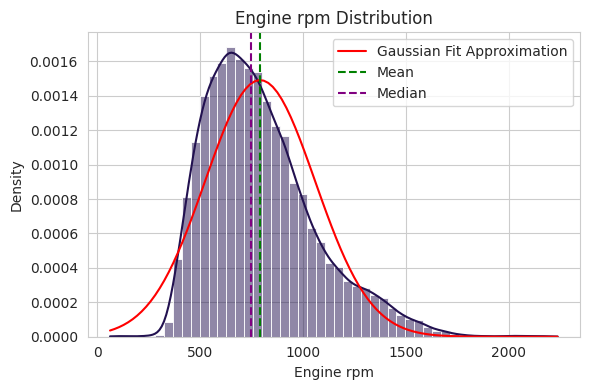

Engine rpm → Shapiro p-value = 0.00000 → Not Normally Distributed


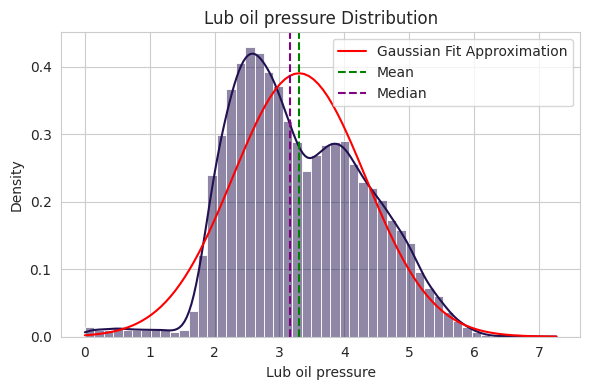

Lub oil pressure → Shapiro p-value = 0.00000 → Not Normally Distributed


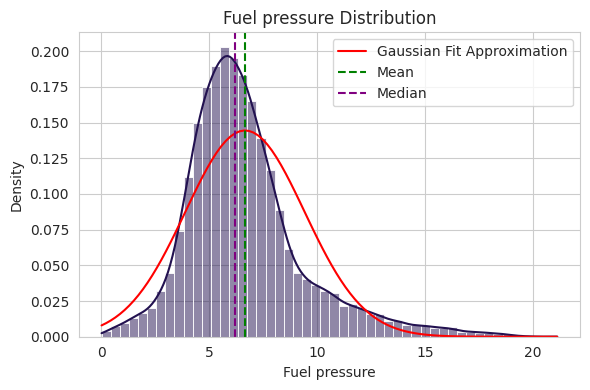

Fuel pressure → Shapiro p-value = 0.00000 → Not Normally Distributed


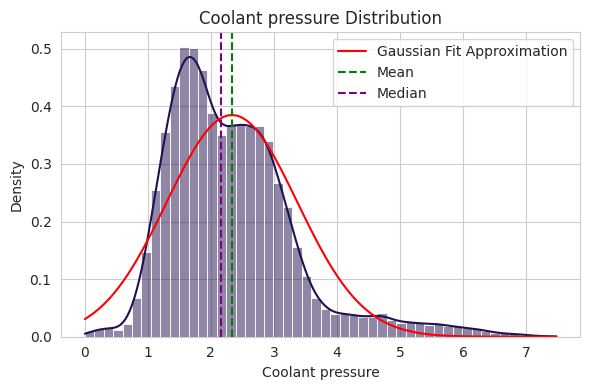

Coolant pressure → Shapiro p-value = 0.00000 → Not Normally Distributed


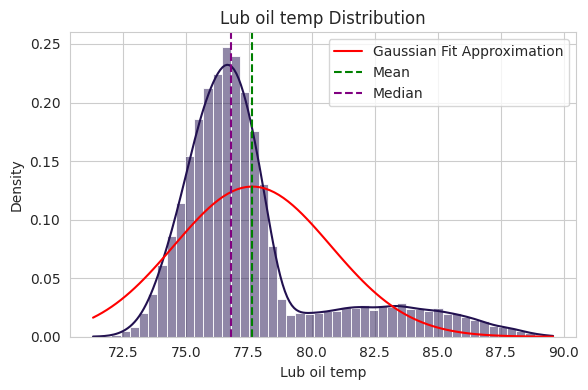

Lub oil temp → Shapiro p-value = 0.00000 → Not Normally Distributed


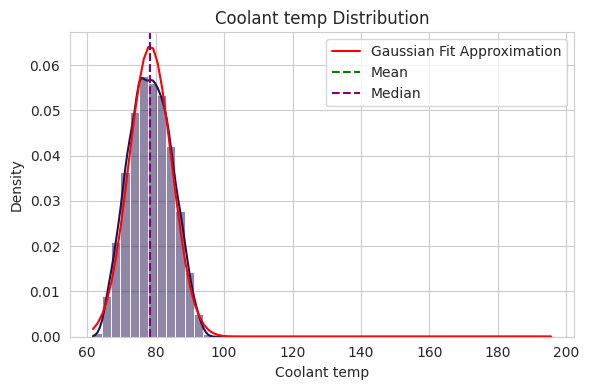

Coolant temp → Shapiro p-value = 0.00000 → Not Normally Distributed


In [5]:
features = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'Lub oil temp', 'Coolant temp']

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[feature], kde=True, bins=50, stat="density")


    # Overlay Gaussian curve
    mu, std = df[feature].mean(), df[feature].std()
    x = np.linspace(df[feature].min(), df[feature].max(), 100)
    p = stats.norm.pdf(x, mu, std)
    plt.plot(x, p, 'r', label='Gaussian Fit Approximation')
    plt.axvline(mu, color='green', linestyle='dashed', linewidth=1.5, label='Mean')
    plt.axvline(df[feature].median(), color='purple', linestyle='dashed', linewidth=1.5, label='Median')
    plt.title(f'{feature} Distribution')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Shapiro-Wilk Test for Normality
    stat, p = shapiro(df[feature])
    print(f"{feature} → Shapiro p-value = {p:.5f} → {'Normal Distribution' if p > 0.05 else 'Not Normally Distributed'}")


In [7]:
# OPTIONAL: Normalisation Test
from scipy.stats import shapiro

features = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'Lub oil temp', 'Coolant temp']

for feature in features:
  # Extract the data for the feature
  data = df[feature]
  # Shapiro-Wilk test
  statistic, p_value = shapiro(data)
  print('p-value: {p_value}'.format(p_value=p_value))

  alpha = 0.05  # Significance level 95%

  if p_value > alpha:
    print("Data trend suggests normal distribution (fail to reject null hypothesis)")
  else:
        print("Data trend does not suggest normal distribution (reject null hypothesis)")

  # Print the results
  print(f"Feature: {feature}")
  print(f"Shapiro-Wilk Statistic: {statistic:.3f} \n")

# Interpret the results

p-value: 4.530809370789583e-63
Data trend does not suggest normal distribution (reject null hypothesis)
Feature: Engine rpm
Shapiro-Wilk Statistic: 0.947 

p-value: 8.721140912794204e-44
Data trend does not suggest normal distribution (reject null hypothesis)
Feature: Lub oil pressure
Shapiro-Wilk Statistic: 0.982 

p-value: 1.8839917827584294e-70
Data trend does not suggest normal distribution (reject null hypothesis)
Feature: Fuel pressure
Shapiro-Wilk Statistic: 0.924 

p-value: 7.502727353677211e-73
Data trend does not suggest normal distribution (reject null hypothesis)
Feature: Coolant pressure
Shapiro-Wilk Statistic: 0.915 

p-value: 4.532667238800205e-87
Data trend does not suggest normal distribution (reject null hypothesis)
Feature: Lub oil temp
Shapiro-Wilk Statistic: 0.839 

p-value: 4.584787358513761e-43
Data trend does not suggest normal distribution (reject null hypothesis)
Feature: Coolant temp
Shapiro-Wilk Statistic: 0.982 



In [8]:
# IQR - based Outlier Detection
outlier_flags = pd.DataFrame(index=df.index)

for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_flags[feature + '_outlier'] = ((df[feature] < lower) | (df[feature] > upper)).astype(int)
    print(f"{feature} — Outlier bounds: {lower:.2f} to {upper:.2f}")

Engine rpm — Outlier bounds: 81.50 to 1445.50
Lub oil pressure — Outlier bounds: 0.21 to 6.36
Fuel pressure — Outlier bounds: 0.67 to 11.99
Coolant pressure — Outlier bounds: -0.27 to 4.72
Lub oil temp — Outlier bounds: 72.21 to 81.59
Coolant temp — Outlier bounds: 60.37 to 96.45


# 1.4 The range values beyond the 95th percentile for at least two features are identified

In [9]:
# define 95th exclusive range for all features by first sorting the data into ascending order
df_95th_range = df.sort_values(by=features, ascending=True)

# int loc indexing subsets rows for len rows *.95 to extract index loc, int reconverts row index to integer (mandatory to avoid error message) and extract
df_95th_range = df_95th_range.iloc[int(len(df_95th_range) * 0.95):]

# print the indices of the rows above percentile 0.95
print(f'Rows with Indices beyond the 95th percentile:', '\n', df_95th_range.index, '\n')

# Frequency of every row that is unique [set of values] to return a series
print(f'Frequency of Unique Row Value-Sets beyond the 95th percentile:', '\n',df_95th_range.value_counts())

Rows with Indices beyond the 95th percentile: 
 Index([ 3444, 11860, 17932,  6245,  5014, 14691,  8940, 13263, 12739, 12538,
       ...
       14564, 18990, 16554,  5970, 12215,  9275, 10506, 13191,  7790, 15932],
      dtype='int64', length=977) 

Frequency of Unique Row Value-Sets beyond the 95th percentile: 
 Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  Lub oil temp  Coolant temp
2239.0      5.314914          1.968075       1.164791          77.108198     76.494411       1
1324.0      2.549917          6.843023       5.814004          77.677628     90.676154       1
            2.701245          4.145118       2.245273          81.290427     78.727466       1
            5.185338          4.239409       0.747233          77.483464     81.372361       1
1325.0      2.035611          5.528491       2.468868          74.424597     79.819057       1
                                                                                            ..
1328.0      4.281546      

In [ ]:
# Are there symptomatic outliers across the fleet indicative of faulty machine parts?
# IQR outlier detection counts
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers")


Engine rpm: 464 outliers
Lub oil pressure: 66 outliers
Fuel pressure: 1135 outliers
Coolant pressure: 785 outliers
Lub oil temp: 2617 outliers
Coolant temp: 2 outliers


In [11]:
# Calculate the 95th percentile for each feature USES THE COLUMNS BOTTOM 5%
percentile = df[features].quantile(0.95) # Subset 'df' to only include the original features

# Create a boolean mask checking for rows with a value greater than the corresponding 95th percentile using .any(axis=1) and filter them
mask = (df[features] > percentile).any(axis=1)

# Count the filtered rows
row_count = mask.sum()
row_count

np.int64(5124)

In [12]:
# Create the new DataFrame using the mask filters
percentile_df = df[mask]
percentile_df.head()
percentile_df.shape

#print(f'There are {percentile_df.shape} rows and columns in the DataFrame')

(5124, 6)

# 2. Anomaly detection: Statistical methods to identify engines with problems

In [13]:
#Use the interquartile range (IQR) method to identify outliers for each feature.
import scipy.stats

# Axis=1 for row-wise IQR calculations and keepdims=True to preserve shape
scipy.stats.iqr(df, axis=1, rng=(25, 75), nan_policy='raise', interpolation='linear', keepdims=True) #‘linear’ method: i + (j - i)*fraction, where fraction is the fractional part of the index surrounded by i and j. Ref: https://docs.scipy.org/doc/scipy-1.15.0/reference/generated/scipy.stats.iqr.html#:~:text=interpolationstr%2C%20optional

array([[71.38442928],
       [68.58442523],
       [82.24774023],
       ...,
       [70.63133244],
       [77.10656058],
       [72.35066788]])

In [14]:
# Compute IQR for each row
iqr_values = stats.iqr(df, axis=1)
print(iqr_values)

[71.38442928 68.58442523 82.24774023 ... 70.63133244 77.10656058
 72.35066788]


In [15]:
# Calculate quantiles for IQR
for feature in features:
  q1 = df[feature].quantile(0.25)
  q3 = df[feature].quantile(0.75)
  # Calculate IQR
  iqr = q3 - q1
  # Define upper and lower bounds
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  # View the output.
  print(f'The {feature} value of Q1 is: {q1}.')
  print(f'The {feature} value of Q3 is: {q3}.')
  print(f'The {feature} value of IQR is: {iqr}.', '\n')
  print(f'The {feature} value of the lower bound is: {lower_bound}.')
  print(f'The {feature} value of the upper bound is: {upper_bound}.', '\n')

The Engine rpm value of Q1 is: 593.0.
The Engine rpm value of Q3 is: 934.0.
The Engine rpm value of IQR is: 341.0. 

The Engine rpm value of the lower bound is: 81.5.
The Engine rpm value of the upper bound is: 1445.5. 

The Lub oil pressure value of Q1 is: 2.5188147159999996.
The Lub oil pressure value of Q3 is: 4.0552715195.
The Lub oil pressure value of IQR is: 1.5364568035000001. 

The Lub oil pressure value of the lower bound is: 0.21412951074999942.
The Lub oil pressure value of the upper bound is: 6.35995672475. 

The Fuel pressure value of Q1 is: 4.916886097.
The Fuel pressure value of Q3 is: 7.7449733335.
The Fuel pressure value of IQR is: 2.8280872365. 

The Fuel pressure value of the lower bound is: 0.6747552422499998.
The Fuel pressure value of the upper bound is: 11.987104188250001. 

The Coolant pressure value of Q1 is: 1.6004658630000002.
The Coolant pressure value of Q3 is: 2.848839661.
The Coolant pressure value of IQR is: 1.2483737979999998. 

The Coolant pressure val

# 1.5 Visualizations created to facilitate understanding of the data

In [ ]:
 #isualise the data to determine the distribution and extreme values.
df_violin = df.melt(value_vars=['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'Lub oil temp', 'Coolant temp' ],
                  var_name='Features',
                  value_name='Values')

plt.figure(figsize=(9, 6))
sns.violinplot(data=df_violin, x='Features', y='Values', inner='quartile')
sns.pointplot(data=df_violin, x='Features', y='Values',
              estimator=np.mean, color='red', markers='d', linestyles='')
plt.title("Violin Plots with Mean (Red Diamonds)")
plt.show()


# 2.2 A new binary column was created for each feature, indicating whether values are outliers based on IQR calculations.

In [16]:
# COUNT UP ROWS THAT SHOW AN ANOMALY IN ANY ROW - BUT COUNT EACH ONLY ONCE
# IF THERE IS A VALUE IN ANY COLUMN, ENGINE INDEX = FALSE

# The Interquartile Range (IQR) method was used to detect outliers in the data.
outlier_flags = pd.DataFrame(index=df.index)

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_col = f"{col}_outlier"
    outlier_flags[outlier_col] = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).astype(int)

df = pd.concat([df, outlier_flags], axis=1)
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,Lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,Lub oil temp_outlier,Coolant temp_outlier
0,682.0,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0
1,605.0,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0
2,658.0,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0
3,749.0,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0
4,676.0,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0


# 2.3 Identify the number of features that must simultaneously be in outlier condition, in order for a sample to be classified as an outlier, such that the total percentage of samples identified as outliers falls within the 1-5% range.

In [19]:
# The new column total and % to distinguish rows without anomalies
# Create the 'iqr_anomaly' column as 'total outlier flags'
df['total_outlier_flags'] = outlier_flags.sum(axis=1)
print("Outlier flag counts per row:")
print(df['total_outlier_flags'].value_counts())

Outlier flag counts per row:
total_outlier_flags
0    14899
2     4214
4      411
6       11
Name: count, dtype: int64


In [21]:
# Classify as outlier if >= N features are flagged (adjust N to fit 1-5%)
for n in range(1, outlier_flags.shape[1] + 1):
    percentage = (df['total_outlier_flags'] >= n).mean() * 100
    print(f"{n} or more features flagged => {percentage:.2f}% of rows")

1 or more features flagged => 23.73% of rows
2 or more features flagged => 23.73% of rows
3 or more features flagged => 2.16% of rows
4 or more features flagged => 2.16% of rows
5 or more features flagged => 0.06% of rows
6 or more features flagged => 0.06% of rows
7 or more features flagged => 0.00% of rows


In [23]:
# >+2 outliers flagged
outlier_flags['total_outlier_flags'] = outlier_flags.sum(axis=1)
df['is_anomaly_iqr'] = (outlier_flags['total_outlier_flags'] >= 2).astype(int)
print("Samples flagged as anomalies (>=2 features outlier):", df['is_anomaly_iqr'].sum())

Samples flagged as anomalies (>=2 features outlier): 4636


In [24]:
df.info() # is there a second data type in the dataset for use with RFE later?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Engine rpm                19535 non-null  float64
 1   Lub oil pressure          19535 non-null  float64
 2   Fuel pressure             19535 non-null  float64
 3   Coolant pressure          19535 non-null  float64
 4   Lub oil temp              19535 non-null  float64
 5   Coolant temp              19535 non-null  float64
 6   Engine rpm_outlier        19535 non-null  int64  
 7   Lub oil pressure_outlier  19535 non-null  int64  
 8   Fuel pressure_outlier     19535 non-null  int64  
 9   Coolant pressure_outlier  19535 non-null  int64  
 10  Lub oil temp_outlier      19535 non-null  int64  
 11  Coolant temp_outlier      19535 non-null  int64  
 12  is_anomaly_iqr            19535 non-null  int64  
 13  total_outlier_flags       19535 non-null  int64  
dtypes: flo

# 2.4 Thoughts about IQR as a means of detecting outliers

An anomaly is 'something that deviates from what is standard, normal, or expected' (Oxford Languages) and it is detected by comprehension of normality. Any resultant outcome should, therefore, use a simple prediction model to test the reliability of the smaller, outlier dataset that is generated by anomaly detection methods. The 11 outliers identified suggest that they are representative of real anomalous results and, in the context of this problem, could hold the key to addressing the task at hand; that is to say, the identification of root failure of so many ship engines. The method used to identify the suspicious occurences during the ship's operation was selected because it is robust to outliers, unlike standard deviation, because it has strict upper and lower bounds at the 0.25 and 0.75 percentiles. The interpretability of the result is also noteworthy, since the Interquartile Range (IQR) is a simple and transparent equation (𝑄1 - 1.5 * IQR, Q1-1.5IQR and Q3+1.5IQR) that is not dependent on a distribution type (Gaussian, Poisson, Binomial). It requires a complete dataset of uninterrupted parameters that makes it unsuitable for very large datasets, those with a high proportion of outliers and streamed real-time datasets with evolutionary values.

Notwithstanding criticism, its usage in this work is loosely defined as pertinent or sagacious because the distributions of the data features are not exclusively univariate, or an approximation. Where data is highly skewed, as is the case in some features (Coolant and Lubricating Oil - see cell amd cell ), IQR method is less likely to detect anomalies. The analysis could be repeated following an adjustment based on a log-scale in order to eliminate skew. Underperfomance does result where the dataset has a high number of dimensions or is periodic/seasonal in nature, such as financial markets data analysis. Consequently, it is not a method that I recommend for use with large and complex engine systems. The high-dimensionality of the data, I summise, was erroneously adjusted in order to create a human-centred approach to analysis of the engine and, as a result of a failure to maintain the inter-relationship between engines on-board a ship, definitive outcomes for this problem are not forthcoming. This dataset requires additional anomaly detection methods, for example z-scores, isolation forests, or clustering-based methods. Modified versions of IQR in addition to box plots would also greatly benefit this analysis.

# 3 Anomaly detection: Machine learning (ML) models

# 3.1 Features in the dataset are scaled to improve model performance

In [25]:
#df.drop(columns=['is_anomaly_iqr'], inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

In [27]:
# PCA on X_scaled, 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Store PCA results in DataFrame
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

#pca_df['is_anomaly_iqr'] = df['is_anomaly_iqr']

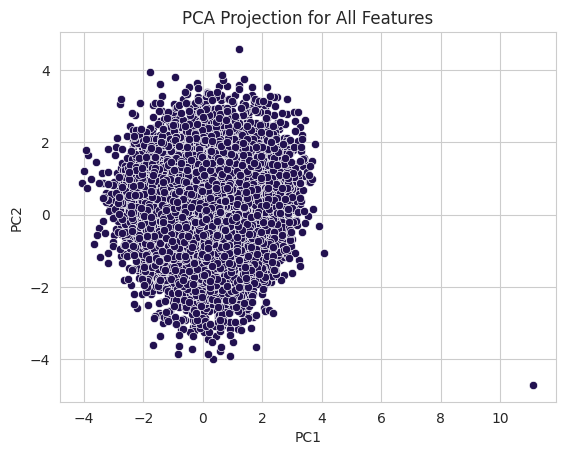

In [28]:
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

sns.scatterplot(data=df_pca, x='PC1', y='PC2')
plt.title('PCA Projection for All Features')
plt.show()

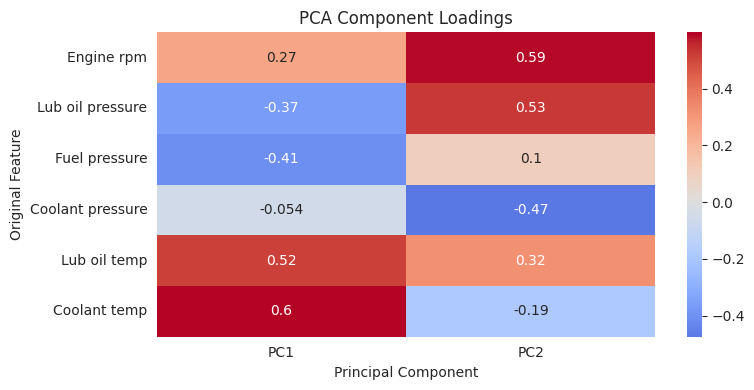

In [29]:
# Calculate PCA loadings (component contributions of each feature)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=features
)
# Also generate a PCA scatter plot color-coded by a selected feature (Fuel Pressure)
pca_df["Fuel pressure"] = df["Fuel pressure"]  # add original feature for coloring

# Heatmap of PCA Loadings
plt.figure(figsize=(8, 4))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Component Loadings")
plt.ylabel("Original Feature")
plt.xlabel("Principal Component")
plt.tight_layout()
plt.show()

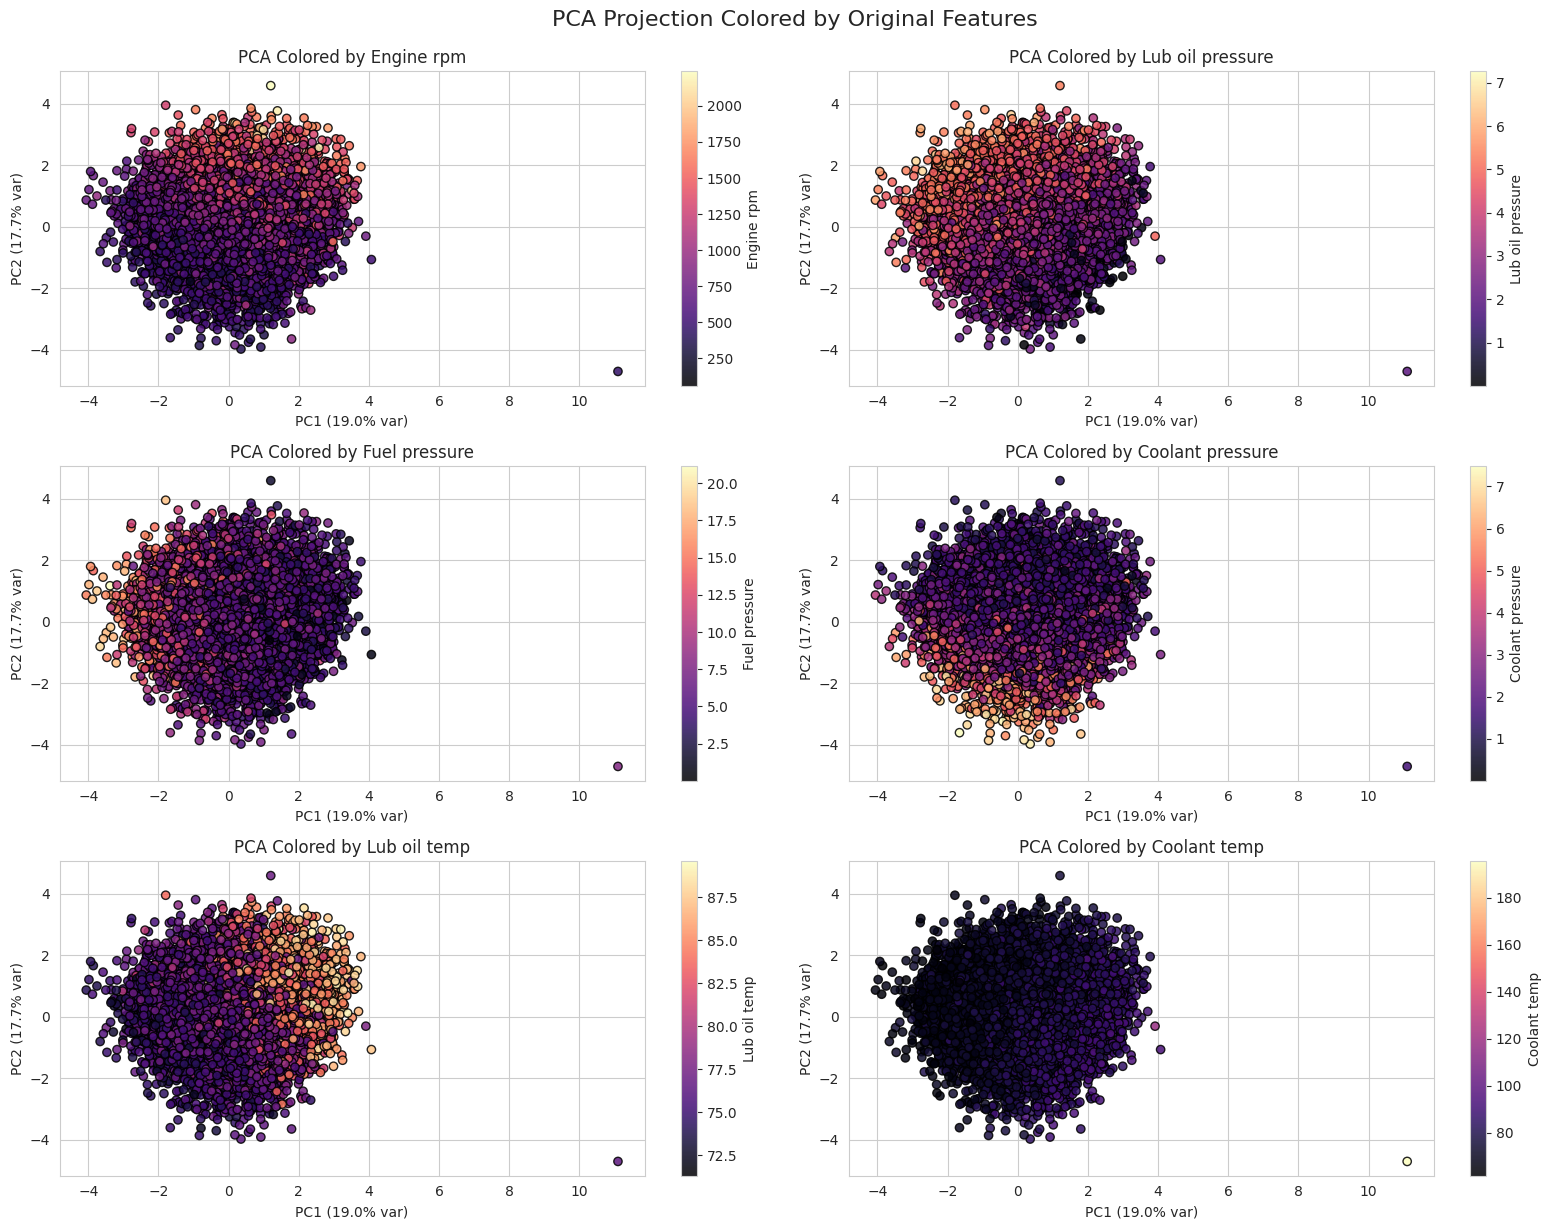

In [30]:
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

sns.set_style("whitegrid")
palette = sns.color_palette("magma", as_cmap=False)
sns.set_palette(palette)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sc = axes[i].scatter(
        pca_df["PC1"], pca_df["PC2"],
        c=df[feature],
        cmap="magma",
        edgecolor="black",
        alpha=0.85
    )
    axes[i].set_title(f"PCA Colored by {feature}")
    axes[i].set_xlabel(f"PC1 ({pc1_var:.1f}% var)")
    axes[i].set_ylabel(f"PC2 ({pc2_var:.1f}% var)")
    plt.colorbar(sc, ax=axes[i], label=feature)

plt.tight_layout()
plt.suptitle("PCA Projection Colored by Original Features", fontsize=16, y=1.02)
plt.show()


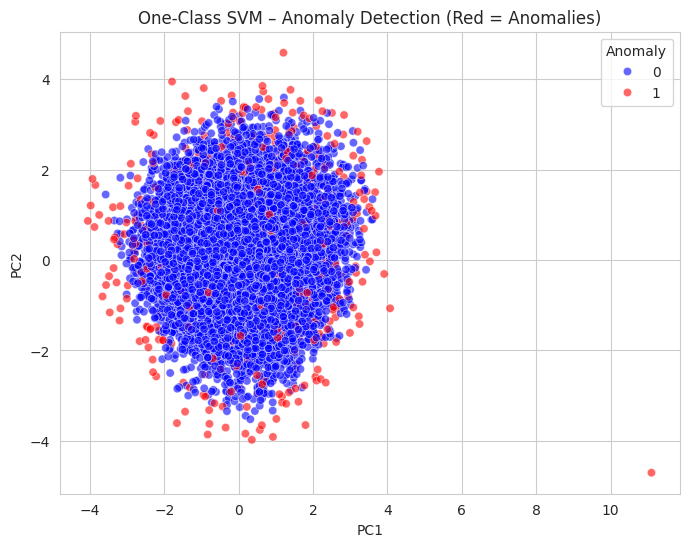

SVM anomalies detected: 585


In [32]:
# Apply magma color scheme
sns.set_style("whitegrid")
palette = sns.color_palette("magma", as_cmap=False)
sns.set_palette(palette)

'''

# Generate 6 PCA subplots, each representing a different original feature
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sc = axes[i].scatter(
        pca_df["PC1"], pca_df["PC2"],
        c=df[feature],
        cmap="magma",
        edgecolor="black",
        alpha=0.85
    )
    axes[i].set_title(f"PCA Colored by {feature}")
    axes[i].set_xlabel(f"PC1 ({pc1_var:.1f}% var)")
    axes[i].set_ylabel(f"PC2 ({pc2_var:.1f}% var)")
    plt.colorbar(sc, ax=axes[i], label=feature)

plt.tight_layout()
plt.suptitle("PCA Projection Colored by Original Features", fontsize=16, y=1.02)
plt.show()'''

from sklearn.svm import OneClassSVM

# Fit One-Class SVM
oc_svm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.03)  # Tune 'nu' to control anomaly rate
oc_pred = oc_svm.fit_predict(X_scaled)

# Convert predictions to 0 (normal) and 1 (anomaly)
df['anomaly_svm'] = (oc_pred == -1).astype(int)
pca_df['anomaly_svm'] = df['anomaly_svm']

# Plot the anomalies
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='anomaly_svm', palette={0: 'blue', 1: 'red'}, alpha=0.6)
plt.title("One-Class SVM – Anomaly Detection (Red = Anomalies)")
plt.legend(title='Anomaly')
plt.show()

print("SVM anomalies detected:", df['anomaly_svm'].sum())


Selected Features: ['Lub oil pressure' 'Fuel pressure' 'Lub oil temp' 'Coolant temp']
Explained variance: PC1 = 28.3%, PC2 = 25.0%


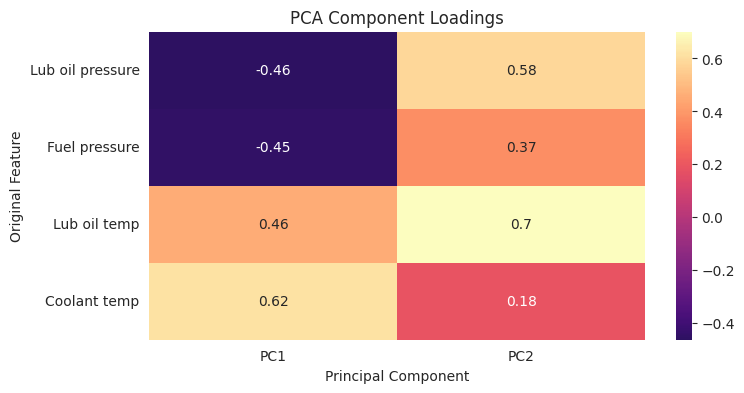

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.cluster import KMeans # For unsupervised target

# reate a proxy y-target using clustering
kmeans = KMeans(n_clusters=2, random_state=42) # Assuming 2 clusters for anomaly/normal
cluster_labels = kmeans.fit_predict(X_scaled)

# Apply RFE using cluster labels as the alternative data tyoe y-target
rfe_model = LogisticRegression(solver='liblinear')
selector = RFE(rfe_model, n_features_to_select=4)
X_rfe = selector.fit_transform(X_scaled, cluster_labels)

selected_features = np.array(features)[selector.support_]
print("Selected Features:", selected_features)

# PCA on reduced features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_rfe)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
explained = pca.explained_variance_ratio_
print(f"Explained variance: PC1 = {explained[0]*100:.1f}%, PC2 = {explained[1]*100:.1f}%")

# Loadings heatmap
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=selected_features)
plt.figure(figsize=(8, 4))
sns.heatmap(loadings, annot=True, cmap='magma', center=0)
plt.title("PCA Component Loadings")
plt.ylabel("Original Feature")
plt.xlabel("Principal Component")
plt.show()


# 3.2 One-class SVM was used for outlier detection to explore various approaches

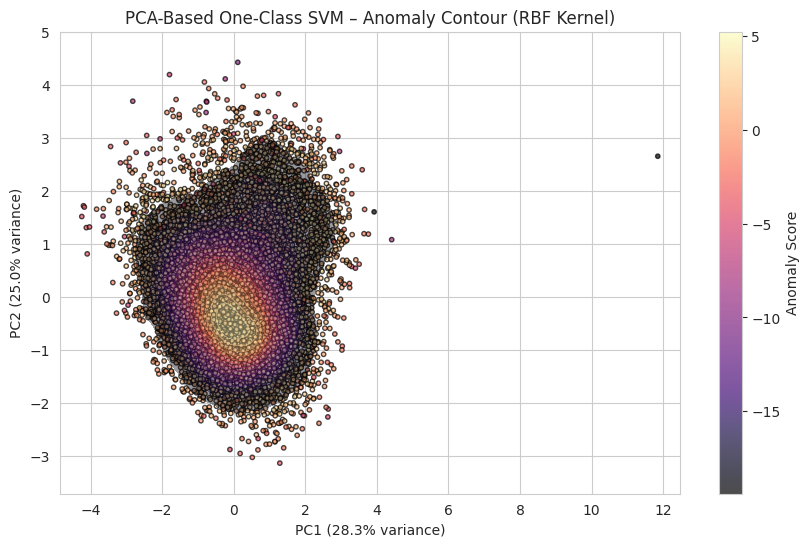

In [37]:
from sklearn.svm import OneClassSVM # Import OneClassSVM

svm = OneClassSVM(kernel='rbf', nu=0.02, gamma='scale')
svm.fit(X_rfe)
scores_svm = svm.decision_function(X_rfe)
df['anomaly_ocsvm'] = svm.predict(X_rfe)
df_pca['SVM Score'] = scores_svm
df_pca['anomaly_ocsvm'] = df['anomaly_ocsvm']

plt.figure(figsize=(10, 6))
grid = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=scores_svm, cmap='magma', s=10, edgecolor='k', alpha=0.7)
plt.colorbar(grid, label='Anomaly Score')
sns.kdeplot(
    x=df_pca['PC1'], y=df_pca['PC2'], fill=True, cmap='magma', levels=15, alpha=0.4, linewidths=1
)
plt.title("PCA-Based One-Class SVM – Anomaly Contour (RBF Kernel)")
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.grid(True)
plt.show()

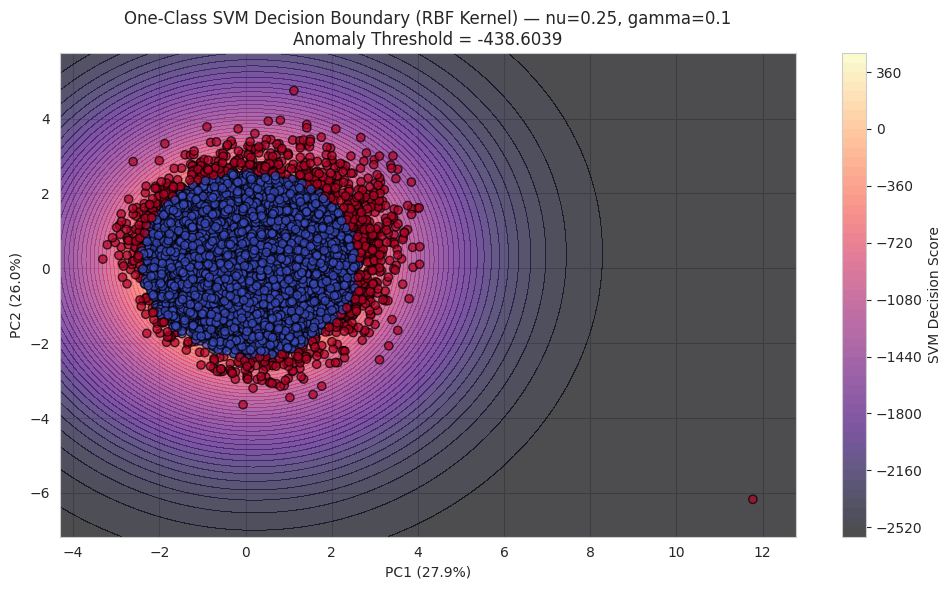

In [38]:
# Fix RFE by providing a dummy binary target, continue with RBF kernel for One-Class SVM, and show final plot
from sklearn.svm import OneClassSVM

# Create mock binary labels just to make RFE work
dummy_y = np.random.choice([0, 1], size=X_scaled.shape[0])

# RFE with dummy labels
estimator = LogisticRegression(solver='liblinear')
selector = RFE(estimator, n_features_to_select=4)
X_rfe = selector.fit_transform(X_scaled, dummy_y)

# PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_rfe)
explained_var = pca.explained_variance_ratio_
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# One-Class SVM with RBF kernel
nu = 0.25
gamma = 0.1
svm = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
svm.fit(X_pca)
scores = svm.decision_function(X_pca)
df_pca['score'] = scores
df_pca['flagged'] = (scores < np.percentile(scores, 5)).astype(int)

# Meshgrid for contour
xx, yy = np.meshgrid(
    np.linspace(df_pca['PC1'].min() - 1, df_pca['PC1'].max() + 1, 300),
    np.linspace(df_pca['PC2'].min() - 1, df_pca['PC2'].max() + 1, 300)
)
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot the final decision boundary
plt.figure(figsize=(10, 6))
contour = plt.contourf(xx, yy, Z, levels=50, cmap='magma', alpha=0.7)
plt.colorbar(contour, label="SVM Decision Score")
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['flagged'], cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title(f"One-Class SVM Decision Boundary (RBF Kernel) — nu={nu}, gamma={gamma}\nAnomaly Threshold = {np.percentile(scores, 5):.4f}")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [51]:
# 2 outliers >= for svm
svm_outlier_flags = pd.DataFrame(index=df.index)

for col in df.columns:
    svm_outlier_column = f"svm_{col}_outlier"
    svm_outlier_flags[svm_outlier_column] = df_pca['score'] = scores

df = pd.concat([df, svm_outlier_flags], axis=1)
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,Lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,...,svm_svm_Lub oil pressure_outlier_outlier_outlier,svm_svm_Fuel pressure_outlier_outlier_outlier,svm_svm_Coolant pressure_outlier_outlier_outlier,svm_svm_Lub oil temp_outlier_outlier_outlier,svm_svm_Coolant temp_outlier_outlier_outlier,svm_svm_is_anomaly_iqr_outlier_outlier,svm_svm_total_outlier_flags_outlier_outlier,svm_svm_anomaly_svm_outlier_outlier,svm_svm_anomaly_ocsvm_outlier_outlier,svm_total_svm_outlier_flags_outlier
0,682.0,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,...,44.996843,44.996843,44.996843,44.996843,44.996843,44.996843,44.996843,44.996843,44.996843,44.996843
1,605.0,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,...,6.427070,6.427070,6.427070,6.427070,6.427070,6.427070,6.427070,6.427070,6.427070,6.427070
2,658.0,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,...,48.687462,48.687462,48.687462,48.687462,48.687462,48.687462,48.687462,48.687462,48.687462,48.687462
3,749.0,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,...,49.947327,49.947327,49.947327,49.947327,49.947327,49.947327,49.947327,49.947327,49.947327,49.947327
4,676.0,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,...,24.150509,24.150509,24.150509,24.150509,24.150509,24.150509,24.150509,24.150509,24.150509,24.150509


In [63]:
df['total_svm_outlier_flags'] = svm_outlier_flags.sum(axis=1)
for n in range(1, svm_outlier_flags.shape[1] + 1):
    percentage = (df['total_svm_outlier_flags'] >= n).mean() * 100
    print(percentage)
    print(f"{n} or more features flagged => {percentage:.2f}% of rows")



94.9884822114154
1 or more features flagged => 94.99% of rows
94.9884822114154
2 or more features flagged => 94.99% of rows
94.9833631942667
3 or more features flagged => 94.98% of rows
94.9833631942667
4 or more features flagged => 94.98% of rows
94.978244177118
5 or more features flagged => 94.98% of rows
94.97312515996929
6 or more features flagged => 94.97% of rows
94.95776810852317
7 or more features flagged => 94.96% of rows
94.95264909137445
8 or more features flagged => 94.95% of rows
94.93729203992834
9 or more features flagged => 94.94% of rows
94.92193498848222
10 or more features flagged => 94.92% of rows
94.9116969541848
11 or more features flagged => 94.91% of rows
94.90657793703609
12 or more features flagged => 94.91% of rows
94.90145891988739
13 or more features flagged => 94.90% of rows
94.90145891988739
14 or more features flagged => 94.90% of rows
94.90145891988739
15 or more features flagged => 94.90% of rows
94.88098285129254
16 or more features flagged => 94.88% 

# 3.3 Model settings for One-class SVM were adjusted to obtain the expected range of outliers.

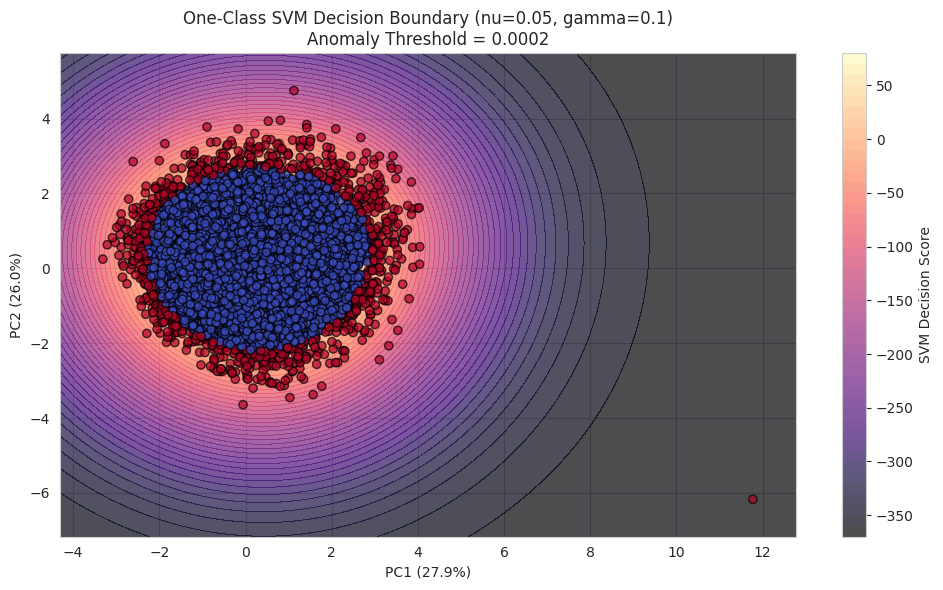

In [64]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_rfe)
explained_var = pca.explained_variance_ratio_
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])


# One-Class SVM
nu = 0.05
gamma = 0.1
svm = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
svm.fit(X_pca)
scores = svm.decision_function(X_pca)
df_pca['score'] = scores
df_pca['flagged'] = (scores < np.percentile(scores, 5)).astype(int)

# Generate meshgrid for decision function
xx, yy = np.meshgrid(
    np.linspace(df_pca['PC1'].min() - 1, df_pca['PC1'].max() + 1, 300),
    np.linspace(df_pca['PC2'].min() - 1, df_pca['PC2'].max() + 1, 300)
)
Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot with contour
plt.figure(figsize=(10, 6))
contour = plt.contourf(xx, yy, Z, levels=50, cmap='magma', alpha=0.7)
plt.colorbar(contour, label="SVM Decision Score")
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['flagged'], cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title(f"One-Class SVM Decision Boundary (nu={nu}, gamma={gamma})\nAnomaly Threshold = {np.percentile(scores, 5):.4f}")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
plt.grid(True)
plt.tight_layout()
plt.show()

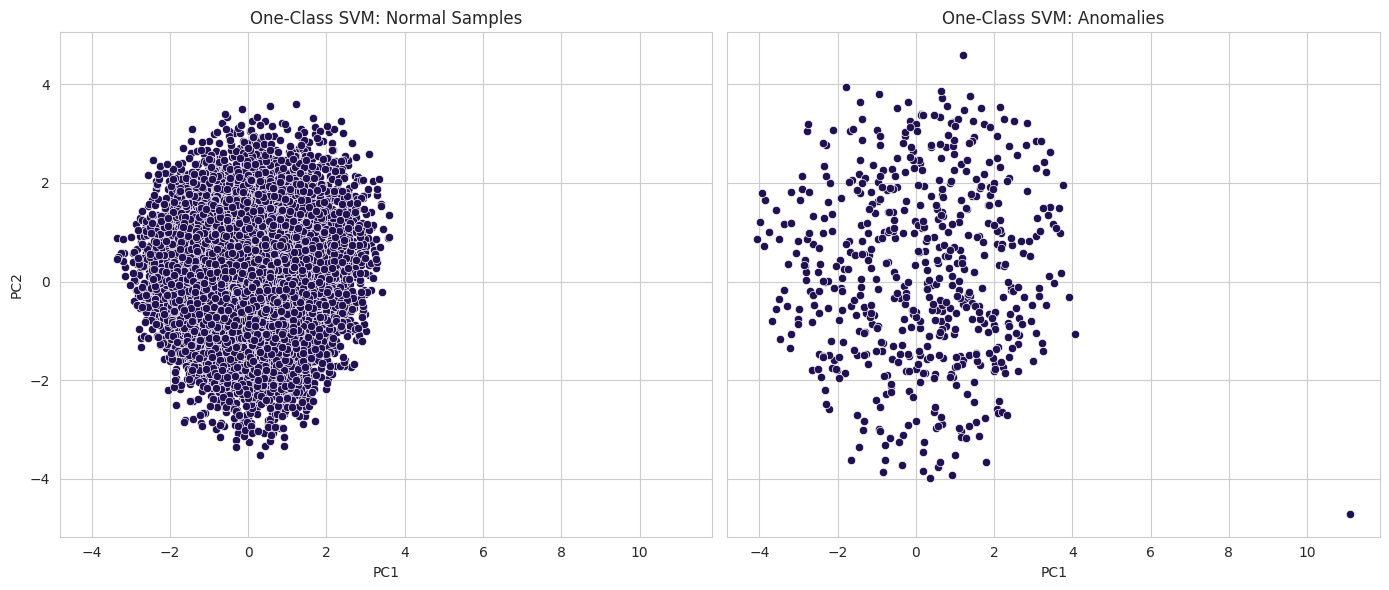

SVM anomalies detected: 586
SVM = 0: 18949
SVM = 1: 586


In [65]:

oc_svm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.03)
df['anomaly_svm'] = (oc_svm.fit_predict(X_scaled) == -1).astype(int)
pca_df['anomaly_svm'] = df['anomaly_svm']

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
sns.scatterplot(data=pca_df[pca_df['anomaly_svm'] == 0], x='PC1', y='PC2', ax=axes[0])
axes[0].set_title("One-Class SVM: Normal Samples")
sns.scatterplot(data=pca_df[pca_df['anomaly_svm'] == 1], x='PC1', y='PC2', ax=axes[1], cmap='magma')
axes[1].set_title("One-Class SVM: Anomalies")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

zero = pca_df['anomaly_svm'] == 0
one = pca_df['anomaly_svm'] == 1
print("SVM anomalies detected:", df['anomaly_svm'].sum())
print("SVM = 0:", zero.sum())
print("SVM = 1:", one.sum())

# 3.4 Isolation Forest was used for outlier detection to explore various approaches.

In [66]:
isf = IsolationForest(contamination=0.05, random_state=42)
# higher anomaly scores are more normal
df['anomaly_isforest'] = isf.fit_predict(X_scaled)

iforest = IsolationForest(contamination=0.025, random_state=42)
df['anomaly_iforest'] = iforest.fit_predict(X_scaled)

print("Isolation Forest contamination 0.05:\n", df['anomaly_isforest'].value_counts())
print("Isolation Forest contamination 0.025:\n", df['anomaly_iforest'].value_counts())

Isolation Forest contamination 0.05:
 anomaly_isforest
 1    18558
-1      977
Name: count, dtype: int64
Isolation Forest contamination 0.025:
 anomaly_iforest
 1    19046
-1      489
Name: count, dtype: int64


# 3.5 Model settings for IF were adjusted to obtain the expected range of outliers

In [90]:
pca_df['anomaly_iforest'] = df['anomaly_iforest'] >= 2

In [91]:
print(pca_df['anomaly_iforest'].sum())

0


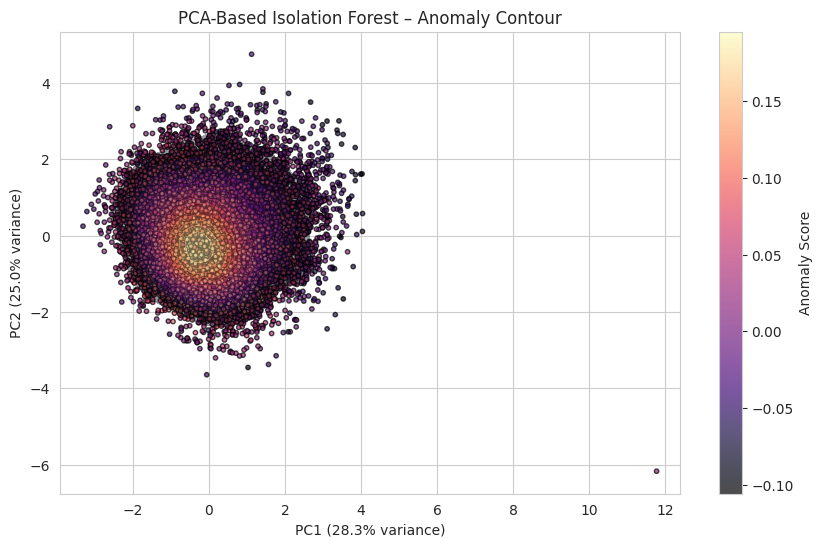

In [93]:
iso = IsolationForest(contamination=0.03, random_state=42)
iso.fit(X_rfe)
scores_iso = iso.decision_function(X_rfe)
df['anomaly_iforest'] = iso.predict(X_rfe)
df_pca['IF Score'] = scores_iso
df_pca['anomaly_iforest'] = df['anomaly_iforest']

plt.figure(figsize=(10, 6))
grid = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=scores_iso, cmap='magma', s=10, edgecolor='k', alpha=0.7)
plt.colorbar(grid, label='Anomaly Score')
sns.kdeplot(
    x=df_pca['PC1'], y=df_pca['PC2'], fill=True, cmap='magma', levels=15, alpha=0.4, linewidths=1
)
plt.title("PCA-Based Isolation Forest – Anomaly Contour")
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.grid(True)
plt.show()

In [ ]:
'''fit_predict(...) returns:
1 = normal
-1 = anomaly

decision_function(...) returns:
Higher = tends to normal
Lower = more anomalous

Use fit_predict() to tag anomalies (1 vs -1)
Use decision_function() to get anomaly scores
Visualize decision boundary, like in One-Class SVM
Normalize and color results in PCA space'''

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

# Style
sns.set_style('whitegrid')
sns.set_palette(sns.color_palette("magma", as_cmap=False))

features = df.columns.tolist()

# Scale feature set
scaler = StandardScaler()
S = scaler.fit_transform(df[features])

# Fit Isolation Forest to data
iorest = IsolationForest(contamination=0.025, random_state=42)
df['anomaly_iforest'] = iforest.fit_predict(S)
scores = iforest.decision_function(S)
threshold = np.percentile(scores, 2.5)

# PCA for 2D visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(S)
explained_var = pca.explained_variance_ratio_
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca['iforest_score'] = scores
df_pca['flagged'] = (scores < threshold).astype(int)

# Plot with magma + anomaly diamonds
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=df_pca['iforest_score'],
    cmap='magma',
    edgecolor='k',
    alpha=0.75,
    s=60
)
plt.colorbar(scatter, label="Isolation Forest Score")

# Overlay flagged anomalies
anomalies = df_pca[df_pca['flagged'] == 1]
plt.scatter(
    anomalies['PC1'],
    anomalies['PC2'],
    marker='D',
    color='red',
    edgecolor='black',
    s=120, # size
    label="Anomalies (Diamonds)"
)

plt.title("Isolation Forest in PCA Space\nAnomalies in Red Diamond Shape")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'sns' is not defined

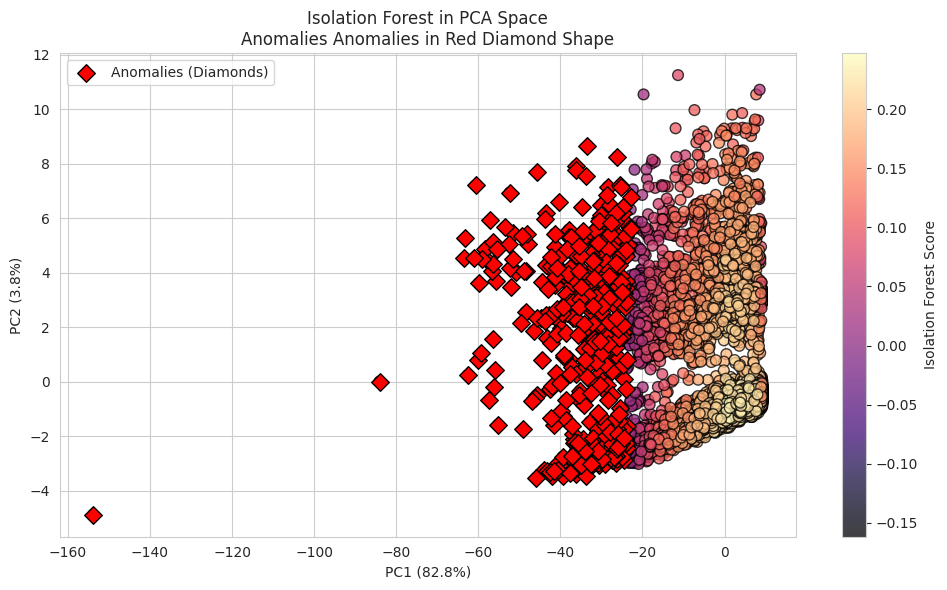

In [97]:
# rescaling for IF
# Recreate the Isolation Forest plot using only real PCA-projected points
# Anomalies shown as 'Diamonds', color by score using magma

# Color map of scores
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=df_pca['iforest_score'],
    cmap='magma',
    edgecolor='k',
    alpha=0.75,
    s=60
)
plt.colorbar(scatter, label="Isolation Forest Score")

# Overlay anomalies as 'Diamond' points
anomalies = df_pca[df_pca['flagged'] == 1]
plt.scatter(
    anomalies['PC1'],
    anomalies['PC2'],
    marker='D',
    color='red',
    edgecolor='black',
    s=80,
    label='Anomalies (Diamonds)'
)

# Create plot
plt.title("Isolation Forest in PCA Space\nAnomalies Anomalies in Red Diamond Shape")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [106]:
# Count anomalies vs normals
anomaly_counts = df['anomaly_iforest'].value_counts()
total_points = len(df)
normal_count = anomaly_counts.get(1, 0)
anomaly_count = anomaly_counts.get(-1, 0)

# Calculate percentages
normal_pct = (normal_count / total_points) * 100
anomaly_pct = (anomaly_count / total_points) * 100
contamination_setting = 0.025

# Construct message

status = "Within expected range (1-5%)" if 1 <= anomaly_pct <= 5 else "Outside expected range (1-5%)"
summary = (
    f"Isolation Forest Results:"
    f"  - Total samples: {total_points}"
    f"  - Normal samples: {normal_count} ({normal_pct:.2f}%)"
    f"  - Anomalous samples: {anomaly_count} ({anomaly_pct:.2f}%)"
    f"  - Contamination parameter: {contamination_setting*100:.2f}%"
    f"  - Status: {status}"
)

summary



'Isolation Forest Results:  - Total samples: 19535  - Normal samples: 19046 (97.50%)  - Anomalous samples: 489 (2.50%)  - Contamination parameter: 2.50%  - Status: Within expected range (1-5%)'